# 00 — Corpus y auditoría de datos

**Autor:** Jason Sepúlveda S.
**Proyecto:** Evaluación experimental de la extracción automática y la representación
persistente de decisiones organizacionales frente a Recuperación Aumentada (RAG)

---

## Qué hace este notebook

Este es el primer registro del proyecto. Documenta tres cosas, en este orden:

1. **Cómo se obtuvo el corpus** y qué contiene realmente.
2. **La auditoría de datos** que exige la sección 5.1 de la propuesta.
3. **Las decisiones de diseño que la auditoría obligó a tomar** — porque varias de ellas
   contradicen lo que la propuesta original establecía.

Ese tercer punto es el más importante y es la razón por la que estos tres temas van en un
solo documento y no en tres: **la secuencia importa**. No se midieron los datos para ilustrar un
plan ya hecho; se midieron los datos y los datos cambiaron el plan.

## Qué NO hace este notebook

No ejecuta el experimento. A esta altura del proyecto no se ha corrido ningún modelo de
lenguaje, no se ha instalado el motor de compilación, y no se ha extraído automáticamente
ninguna decisión. El motor está apagado a propósito: **medir la materia prima antes de
encender la máquina no es un retraso, es el trabajo.**

## Una regla que nos impusimos

Ninguna cifra de este notebook se calcula aquí. Todas vienen de funciones con test en el
paquete `afg` (`src/afg/`). El notebook importa, llama y grafica.

No es purismo. Durante este proyecto se hizo una extrapolación fuera del paquete y se obtuvieron
~170 candidatos; sobre las catorce series reales el filtro daba 712, y la cifra final, tras corregir el punto de operación, es 92 — un error de factor cuatro que solo apareció
al correr la función real sobre el conjunto real. Una celda de notebook es una fuente de
verdad paralela que nadie testea. Si "cuántas decisiones hay" admite dos respuestas, alguna
va a terminar citada en la tesis.

In [1]:
import tomllib

import matplotlib.pyplot as plt
import pandas as pd

from afg import audit
from afg.shared.paths import AMI_DIR, PROJECT_ROOT

pd.set_option("display.max_rows", 80)
pd.set_option("display.width", 120)
plt.rcParams.update({"figure.figsize": (9, 4), "figure.dpi": 110, "axes.grid": True,
                     "grid.alpha": 0.3, "axes.spines.top": False, "axes.spines.right": False})

# Guard: the corpus is gitignored and weighs 228 MB.
if not AMI_DIR.exists() or not any(AMI_DIR.glob("abstractive/*.xml")):
    raise SystemExit(
        f"El corpus AMI no esta en {AMI_DIR}.\n"
        "Descargalo primero con:  uv run afg corpus download"
    )

CFG = tomllib.loads((PROJECT_ROOT / "config" / "corpus.toml").read_text())["oe1"]
SERIES, DEV, EVAL = CFG["series"], CFG["development_series"], CFG["evaluation_series"]

print(f"Corpus en {AMI_DIR.relative_to(PROJECT_ROOT)}")
print(f"Series seleccionadas: {len(SERIES)}  (desarrollo {len(DEV)} / evaluacion {len(EVAL)})")

Corpus en data/raw/ami
Series seleccionadas: 14  (desarrollo 3 / evaluacion 11)


---

# 1. El corpus

Se trabaja sobre el **AMI Meeting Corpus** (Carletta et al., 2006), unas 100 horas de reuniones
grabadas y transcritas manualmente. Dos tercios corresponden a un escenario de diseño de un
control remoto de televisión, organizado en **series de cuatro reuniones con los mismos
cuatro participantes**.

Esa estructura en series es la razón por la que se eligió este corpus: es el sustrato donde una
decisión puede ser revisada, reafirmada o revertida en una reunión posterior, que es
exactamente el fenómeno que se quiere medir.

**Licencia: CC BY 4.0.** La página de licencia no declara fecha de vigencia; abril de 2017 es solo la fecha del paquete de anotaciones. Es un detalle que importa: los artículos
originales del corpus describen una licencia anterior más restrictiva. Al citar las
condiciones de uso hay que citar la página de licencia vigente, no los artículos.

La descarga es un comando del proyecto, no un paso manual:

```bash
uv run afg corpus download
```

Descarga `ami_public_manual_1.6.2.zip` (22,9 MB), verifica que sea un zip válido, lo extrae,
e imprime la licencia antes de escribir nada.

## 1.1 Qué capas de anotación trae, y cuáles están vacías

AMI no es solo transcripciones: trae varias capas de anotación manual superpuestas. Se verificó
cuáles existen realmente en la distribución, porque el diseño depende de tres de ellas.

In [2]:
cov = audit.layer_coverage()
display(cov)

,layer,file_count,meetings_covered,oe1_series_complete_count,oe1_series_incomplete
0,abstractive_summary,142,142,14,
1,extractive_summary_links,137,137,14,
2,decision_discussion_segmentation,47,47,6,"ES2002,ES2008,ES2014,IS1003,IS1009,TS3003,TS30..."
3,dialogue_acts,556,139,14,
4,words,687,171,14,


Las tres capas de las que depende el conjunto de referencia son:

| Capa | Qué aporta |
|---|---|
| `abstractive` | Los resúmenes abstractivos, con una sección `DECISIONS` — de ahí salen las decisiones |
| `extractive` (`summlink`) | El enlace entre cada frase del resumen y los actos de diálogo que la respaldan — de ahí sale la evidencia |
| `dialogueActs` + `words` | La transcripción, para resolver esa evidencia hasta las palabras habladas |

### Un hallazgo sobre la novedad del trabajo

Al revisar la documentación del corpus se encontró que AMI **declara** una capa llamada
`decisionlink`. Se verificó de inmediato, porque una capa de enlaces entre decisiones
haría que el aporte principal del proyecto ya existiera.

No lo hace, y el resultado refuerza el argumento en lugar de debilitarlo. Por tres razones,
todas verificables en la distribución:

1. Enlaza un segmento de decisión con una **frase del resumen**, no con otra decisión.
2. Está declarada como *"one file per observation"* — es decir, **intra-reunión** por
   construcción. No puede expresar una relación entre reuniones.
3. **No se distribuye ningún dato.** El directorio contiene solo los 47 archivos de
   segmentación de decisiones; el censo de elementos da 288 `<decision>` y **cero** punteros
   a los resúmenes.

Es decir: AMI diseñó un espacio para enlaces de decisión, lo declaró en su esquema, y lo
dejó vacío. El sustrato existe desde 2006 y el enlace nunca se anotó.

---

# 2. Verificación estructural: qué hay realmente

La propuesta original fijaba la muestra en las **reuniones que tienen la capa de
*Decision Discussion Segmentation* (DDS)**. Antes de comprometerse con ese marco, se contó.

In [3]:
elig = audit.series_eligibility()
print(f"Series con las 4 reuniones en la capa abstractiva: {len(elig)}")
print(f"  ... y con summlink en las 4:  {int(elig['summlink_on_4_of_4'].sum())}")
print(f"  ... y con capa DDS:           {int(elig['has_dds'].sum())}")
print(f"\nDecisiones totales en las series completas: {int(elig['decision_count'].sum())}")
display(elig.sort_values("decision_count", ascending=False).head(12))

Series con las 4 reuniones en la capa abstractiva: 33
  ... y con summlink en las 4:  32
  ... y con capa DDS:           6

Decisiones totales en las series completas: 649


,series_id,summlink_on_4_of_4,has_dds,decision_count
6,ES2008,True,False,33
23,TS3003,True,False,31
25,TS3005,True,True,29
13,ES2015,True,True,29
0,ES2002,True,False,28
32,TS3012,False,False,26
17,IS1003,True,False,25
29,TS3009,True,False,24
14,ES2016,True,True,24
18,IS1004,True,True,24


### El primer cambio de plano

Aquí apareció el hallazgo que reorientó el proyecto:

| Marco muestral | Series completas de 4 reuniones | Decisiones |
|---|---|---|
| Capa DDS (propuesta original) | **6** | 136 |
| Resúmenes abstractivos | **33** | 649 |

**El cuello de botella nunca fue el corpus: era la capa elegida como marco
muestral.**

Y lo más incómodo es que la propuesta original ya comprometía la capa abstractiva. La sección
5.0 dice que se reutilizan *"los encabezados DECISIONS de los resúmenes abstractivos, enlazados a
actos de diálogo a través del resumen extractivo"* — la operacionalización de Hsueh & Moore.
La frase siguiente anclaba la muestra a las 47 reuniones con DDS. **Esa restricción no la
exigía el método; se heredó sin necesidad.**

La capa DDS no se pierde: pasa de marco muestral a **subconjunto de validación** en las seis
series que tienen ambas capas. Eso da una comprobación de confiabilidad que antes no
existía, y que importa mucho dado lo que se discute en la sección 1.4 de la propuesta sobre la
inestabilidad del constructo "decisión".

---

# 3. Auditoría de datos

La sección 5.1 de la propuesta compromete una auditoría con contenidos específicos: sesgo de
dominio, habla actuada, composición lingüística, fuga de información y el descarte de la
segmentación por tópico como proxy. Esta sección los cubre uno por uno.

## 3.1 Sesgo de dominio y habla actuada

Dos limitaciones que no son corregibles y que se declaran por adelantado:

- **Un solo dominio.** Todas las reuniones del escenario tratan el mismo producto: un control
  remoto de televisión. La generalización a otros dominios organizacionales no es evaluable
  con este corpus y no se afirma.
- **Habla actuada.** Los participantes representan roles asignados. Las decisiones son reales
  como actos conversacionales, pero las consecuencias organizacionales son simuladas.

## 3.2 Composición lingüística

AMI fue construido deliberadamente con una alta proporción de hablantes no nativos de inglés.
**Ningún artículo publica la cifra.** Es computable, así que se computó.

In [4]:
from afg.corpus.participants import load_native_language_records, native_speaker_ratio

recs = load_native_language_records(AMI_DIR)
counts = native_speaker_ratio(recs)
print(f"Participantes en el corpus: {len(recs)}")
print(f"  nativos de ingles : {counts.native}")
print(f"  no nativos        : {counts.non_native}")
print(f"  desconocidos      : {counts.unknown}")
print(f"\nProporcion de no nativos entre los identificables: "
      f"{counts.non_native / (counts.native + counts.non_native):.1%}")

Participantes en el corpus: 189
  nativos de ingles : 91
  no nativos        : 96
  desconocidos      : 2

Proporcion de no nativos entre los identificables: 51.3%


**96 de 187 participantes identificables (51,3 %) no son hablantes nativos de inglés.** Es
una derivación propia; ningún artículo la publica.

Dos precisiones metodológicas:

- El archivo de recursos del corpus trae un atributo `native_language` explícito. La propuesta original
  describía una heurística basada en el tercer carácter del identificador de participante;
  **esa heurística es innecesaria y además falla**. Acierta en 187 de 189 casos, pero para
  toda la serie TS3005 —cuyos participantes no figuran en el archivo— devolvería "neerlandés"
  con total confianza. Es una fabricación. El código conserva la heurística documentada como
  referencia, con un test que fija precisamente ese defecto.
- Los 2 desconocidos tienen el campo vacío. Se reportan como desconocidos, nunca sumados a
  los no nativos. Un campo vacío no es un dato.

### El hallazgo que invalida un eje de análisis

Al cruzar lengua con sitio de grabación apareció algo estructural:

| Sitio | Prefijo | Perfil lingüístico |
|---|---|---|
| Edinburgh | `ES` | Casi todo hablantes nativos |
| Idiap | `IS` | Mayoritariamente no nativos |
| TNO | `TS` | **Ningún participante figura en el archivo de recursos** |

**La lengua materna está perfectamente anidada en el sitio de grabación.** En AMI no se puede
separar "hablante no nativo" de "grabado en Idiap".

La propuesta original declara la estratificación por condición nativo/no nativo como obligatoria y
la llama el eje más relevante de equidad. **Con estos datos esa afirmación no se
sostiene**, y no por tamaño de muestra sino por estructura: dentro del marco muestral de
33 series, el bloque TS completo (alrededor del 30 % de los participantes de esas series)
no figura en `participants.xml`; en el corpus completo solo 2 de 189 son desconocidos, y
la variable está confundida con el sitio. Se baja de estratificación obligatoria a
limitación reportada, y se pasa el **eje de rol del hablante** a análisis primario de
equidad.

## 3.3 Quién decide: autoría por rol

Si el eje de rol pasa a ser el análisis primario de equidad, se necesita algo que la propuesta
no contemplaba: **la tasa base**. ¿Cómo se reparten las decisiones entre los cuatro roles,
antes de que ningún sistema las procese?

Es medible. Cada frase de decisión se enlaza a sus actos de diálogo vía `summlink`, cada acto
identifica al hablante, y el archivo de reuniones da el rol de cada hablante.

,role,site,count,share
14,PM,ALL,322,0.470073
12,ID,ALL,156,0.227737
13,ME,ALL,105,0.153285
15,UI,ALL,102,0.148905


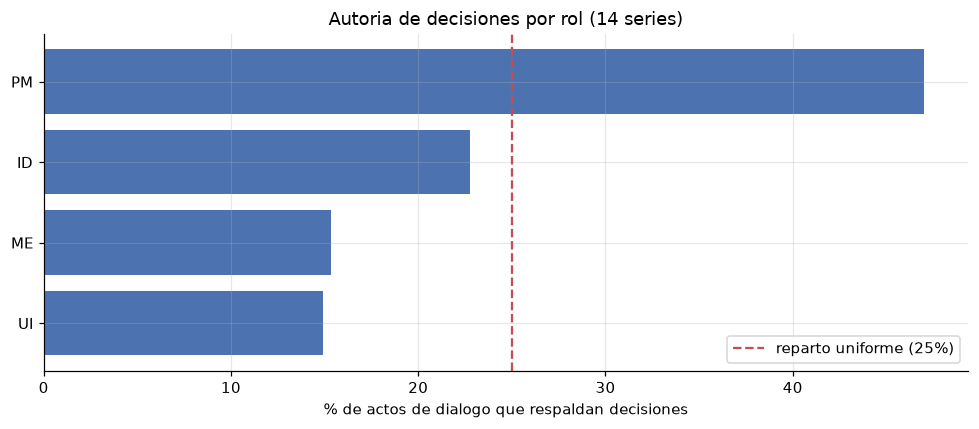

In [5]:
roles = audit.role_authorship(series=SERIES)
total = roles[roles["site"] == "ALL"].sort_values("share", ascending=False)
display(total)

fig, ax = plt.subplots()
ax.barh(total["role"], total["share"] * 100, color="#4C72B0")
ax.axvline(25, color="#C44E52", linestyle="--", label="reparto uniforme (25%)")
ax.set_xlabel("% de actos de dialogo que respaldan decisiones")
ax.set_title("Autoria de decisiones por rol (14 series)")
ax.invert_yaxis()
ax.legend()
plt.tight_layout()
plt.show()

**El Project Manager origina el 47,0 % de la evidencia decisoria**, casi el doble del
reparto uniforme, y más que los otros tres roles juntos en algunos sitios.

Se verificó que no sea un artefacto de un sitio en particular:

In [6]:
by_site = roles[roles["site"] != "ALL"].pivot(index="site", columns="role", values="share")
display((by_site * 100).round(1))

role,ID,ME,PM,UI
site,,,,
ES,20.8,15.1,49.8,14.3
IS,25.4,12.0,44.0,18.7
TS,22.6,18.9,46.5,12.0


La proporción del PM se mantiene entre 44 % y 50 % en los tres sitios. **No es un artefacto de
sitio: es estructural al escenario AMI.**

Esto importa para la evaluación por una razón concreta. La sección 6.3 de la propuesta advierte que un sistema
que extraiga mejor las decisiones de quien preside la reunión amplifica la jerarquía del
registro organizacional. Sin esta línea base, un recall del 47 % para el PM parecería un
sesgo del sistema. **Con ella, se sabría que el sistema simplemente refleja el corpus.** La
pregunta correcta no es si el sistema favorece al PM, sino si lo favorece *más de lo que ya
lo favorece el material*.

## 3.4 Anclaje a evidencia

La definición de decisión (sección 5.2 de la propuesta) exige que esté **anclada**: que exista al menos un
acto de diálogo que la formule o ratifique. Se midió cuántas lo están.

In [7]:
anch = audit.anchoring_rates(series=SERIES)
agg = anch[anch["scope"] == "total"].iloc[0]
print(f"Decisiones:              {int(agg['n_decisions'])}")
print(f"  con evidencia (>=1 acto): {int(agg['n_anchored'])}  ({agg['anchoring_rate']:.1%})")
print(f"  sin evidencia (0 actos):  {int(agg['n_zero_evidence'])}")

per_series = anch[anch["scope"] == "series"].sort_values("anchoring_rate")
display(per_series[["key", "n_decisions", "n_anchored", "n_zero_evidence", "anchoring_rate"]])

Decisiones:              343
  con evidencia (>=1 acto): 317  (92.4%)
  sin evidencia (0 actos):  26


,key,n_decisions,n_anchored,n_zero_evidence,anchoring_rate
54,TS3003,31,24,7,0.774194
34,IS1004,24,20,4,0.833333
14,ES2014,23,20,3,0.869565
69,TS3011,23,21,2,0.913043
4,ES2002,28,26,2,0.928571
59,TS3005,29,27,2,0.931034
39,IS1006,17,16,1,0.941176
49,IS1009,20,19,1,0.950000
64,TS3009,24,23,1,0.958333
29,IS1003,25,24,1,0.960000


**317 de 343 decisiones (92,4 %) tienen evidencia.** Las 26 restantes no son un hueco menor:
son una **señal de triaje**, y esto se descubrió de la peor manera posible.

### El caso del botón turbo

Al construir el ejemplo del manual de anotación se tomó un caso que parecía ideal. En la tercera
reunión de la serie IS1004, el resumen dice que el control tendrá, entre otras cosas, *"a
turbo button"*. En la cuarta reunión, el resumen dice:

> *"For pricing reasons they eliminate the turbo button."*

Una reversión de manual. Salvo que esa frase tiene **cero actos de diálogo** asociados. Se acudió a
la transcripción a buscar la evidencia a mano, y lo que dice es esto:

> *"…the turbo button does add that extra class. So I mean **if we're over budget then maybe
> we could rethink that**. Yeah. **No we're not** — we don't need anything special for the
> buttons. **Make it plastic instead of rubber.** And then we're basically on budget…"*

La eliminación se planteó **condicionada** a estar sobre presupuesto, verificaron que **no**
lo estaban, cerraron el desajuste cambiando goma por plástico, y **el botón se quedó**. Es la
última mención de "turbo" en toda la reunión, revisando los cuatro hablantes.

**El resumen abstractivo de AMI está equivocado.**

Dos consecuencias que se derivan de esto:

1. **`evidencia = 0` predijo el error.** Los propios anotadores de AMI no pudieron anclar esa
   frase. Esa señal ahora es una marca automática de revisión obligatoria.
2. **Si se hubiera confiado en el resumen, se habría escrito una relación temporal falsa** en el
   conjunto de referencia — es decir, en el material que la sección 5.3 de la propuesta define como la
   condición "sin errores de extracción". Un error ahí no se mide: **se convierte en la vara
   con la que se mide todo lo demás.**

Es exactamente el riesgo que se describe en la sección 1.3 de la propuesta, apareciendo en el
material humano de origen y no en la extracción automática.

## 3.5 La forma de las decisiones

Cuánto texto tiene una decisión resultó tener una consecuencia operativa que no se anticipó.

,mediana de tokens de contenido
series_id,
ES2002,3.5
ES2008,4.0
ES2015,4.0
ES2016,4.0
IS1003,4.0
IS1006,5.0
TS3003,5.0
TS3005,5.0
IS1004,6.0


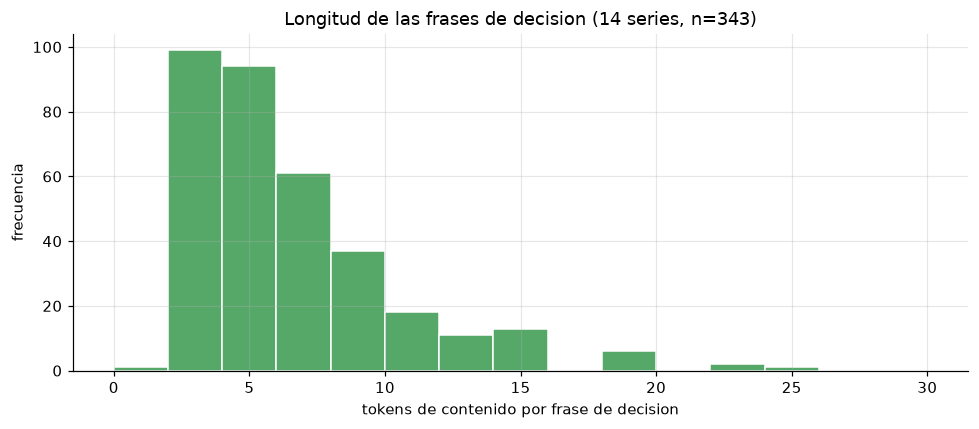

In [8]:
shape = audit.sentence_shape(series=SERIES)
med = (shape.groupby("series_id")["n_tokens"].median()
       .sort_values().rename("mediana de tokens de contenido"))
display(med.to_frame())

fig, ax = plt.subplots()
ax.hist(shape["n_tokens"], bins=range(0, 32, 2), color="#55A868", edgecolor="white")
ax.set_xlabel("tokens de contenido por frase de decision")
ax.set_ylabel("frecuencia")
ax.set_title(f"Longitud de las frases de decision (14 series, n={len(shape)})")
plt.tight_layout()
plt.show()

La mediana va de **3,5 tokens** (ES2002) a **12,0** (IS1008) — un factor de tres entre series.
En la sección 4 se ve por qué esto casi arruina el procedimiento de anotación.

También se contaron los marcadores de propuesta abierta, porque la sección 5.2 de la propuesta necesita las
**no-decisiones** para medir falsos positivos:

In [9]:
marks = audit.non_decision_markers(series=SERIES)
display(marks.head(10))
print(f"\nMarcadores buscados: {', '.join(audit.NON_DECISION_MARKERS)}")

,marker,n_matches,n_sentences,rate
0,will consider,1,343,0.002915
1,will research,1,343,0.002915
2,should be,7,343,0.020408
3,might,0,343,0.000000
4,maybe,0,343,0.000000
5,could,3,343,0.008746



Marcadores buscados: will consider, will research, should be, might, maybe, could


Expresiones como *"will consider"* o *"will research"* marcan cosas que **no** se decidieron.
La definición las excluye de las decisiones, pero las conserva en el conjunto de referencia:
se necesitan para medir cuándo un sistema afirma que algo se decidió cuando no fue así.

El corpus las entrega ya separadas y con marcador lingüístico propio. Es material que de
otro modo habría tenido que fabricarse.

## 3.6 La segmentación por tópico como proxy

La propuesta original descarta usar los límites de tópico como sustituto de los límites de discusión
decisoria, citando a Hsueh & Moore, que reportan coincidencia *"menos de la mitad de las
veces"*.

Como se cuenta con la capa de tópicos descargada, **puede medirse en la muestra del proyecto en vez de
citarlo.**

In [10]:
rows = []
for tol in (5, 10, 20, 40, 80):
    r = audit.topic_decision_boundary_overlap(series=SERIES, tolerance_words=tol)
    rows.append({"tolerancia (palabras)": tol, "segmentos": r.aggregate_n_decisions,
                 "coinciden": r.aggregate_n_aligned, "tasa": r.aggregate_coincidence_rate})
sens = pd.DataFrame(rows)
display(sens.style.format({"tasa": "{:.1%}"}))

,tolerancia (palabras),segmentos,coinciden,tasa
0,5,133,12,9.0%
1,10,133,14,10.5%
2,20,133,15,11.3%
3,40,133,19,14.3%
4,80,133,22,16.5%


**El 9,0 % de los segmentos de discusión decisoria empieza donde empieza un tópico**, con una
tolerancia de 5 palabras. Y la cifra es robusta: incluso con una ventana absurdamente
generosa de 80 palabras solo llega al 16,5 %.

Mucho más bajo que el "menos de la mitad" que cita la propuesta original. El descarte del proxy queda
respaldado por una medición propia sobre las series que efectivamente se van a usar, y no por
una cita.

Una limitación declarada: solo las seis series con capa DDS permiten este cruce, y la
tolerancia en palabras se convierte a una ventana temporal usando la duración media de
palabra de cada reunión, porque los segmentos abarcan canales de hablante numerados de forma
independiente. Es una aproximación documentada en el código, no una medida exacta.

---

# 4. Lo que la auditoría obligó a cambiar

Esta sección es la razón de ser del notebook. Las decisiones siguientes **no estaban en la
propuesta**: salieron de las mediciones anteriores.

## 4.1 Cómo se eligen los pares a anotar

El aporte central del proyecto son las **relaciones temporales entre decisiones de reuniones distintas**.
El problema es combinatorio, y la propuesta no lo aborda.

In [11]:
from afg.annotation import blocking

counts = audit.decision_counts(series=SERIES)

n_pairs = 0
for s in SERIES:
    ds = blocking.decisions_from_abstractive(AMI_DIR, s)
    n_pairs += len(blocking.generate_candidates(ds)) + len(blocking.rejected_pairs(ds))

print(f"Decisiones en las 14 series: {int(counts['n_decisions'].sum())}")
print(f"Pares de decisiones entre reuniones distintas: {n_pairs:,}")
print(f"\nA 1,5 minutos por par, anotarlos todos: {n_pairs * 1.5 / 60:.0f} horas")

Decisiones en las 14 series: 343
Pares de decisiones entre reuniones distintas: 3,071

A 1,5 minutos por par, anotarlos todos: 77 horas


**3.071 pares son inviables para una tesis.** La salida estándar en construcción de datasets
de relaciones es el **bloqueo**: un filtro propone pares candidatos, la persona adjudica solo
esos, y una muestra aleatoria de los descartados estima cuánto se perdió.

El principio que no se negocia: **la máquina decide qué mirar, la persona decide qué dice.**

### Por qué no uso Jaccard

Se probó primero el índice de Jaccard, que es el default en la literatura de bloqueo. Con el par
del botón turbo pasa esto:

In [12]:
earlier_id, later_id = audit.TURBO_BUTTON_PAIR
texts = {d.id: d.content for d in blocking.decisions_from_abstractive(AMI_DIR, "IS1004")}
a, b = blocking.tokenize(texts[earlier_id]), blocking.tokenize(texts[later_id])
print(f"anterior  ({earlier_id}): {texts[earlier_id][:88]}...")
print(f"posterior ({later_id}): {texts[later_id]}\n")
print(f"|A| = {len(a)}   |B| = {len(b)}   interseccion = {sorted(a & b)}")
print(f"\nJaccard              = {blocking.jaccard(a, b):.3f}   -> bajo umbral 0.18: SE PIERDE")
print(f"Coef. de solapamiento = {blocking.overlap_coefficient(a, b):.3f}   -> lo captura")

anterior  (IS1004c.elana.s.29): The remote will have a base station, a button on the base station to press, 2 scroll whe...
posterior (IS1004d.elana.s.22): For pricing reasons they eliminate the turbo button.

|A| = 14   |B| = 5   interseccion = ['button', 'turbo']

Jaccard              = 0.118   -> bajo umbral 0.18: SE PIERDE
Coef. de solapamiento = 0.400   -> lo captura


La razón es estructural, no un ajuste de umbral: **una reversión es casi siempre una frase
corta apuntando a una larga**, y Jaccard divide por la unión, castigando esa asimetría. El
coeficiente de solapamiento divide por el mínimo, y no la castiga.

Un blocker con Jaccard queda sistemáticamente ciego a las reversiones — es decir, ciego al
estrato de preguntas de evolución, que es donde se juega nuestra hipótesis principal.

### Y por qué el coeficiente solo tampoco basta

Aquí se cometió el error que motivó la regla del inicio de este notebook. Se midió la tasa de bloqueo
en dos series piloto, se obtuvo 5,5 %, y se extrapoló ~170 pares. Al correrlo sobre las catorce:

In [13]:
grid = audit.blocker_sensitivity(series=SERIES, thresholds=(0.30, 0.40, 0.50),
                                 min_overlaps=(1, 2, 3))
display(grid)

,threshold,min_overlap_tokens,n_candidates,pct_of_total_pairs,turbo_button_survives
0,0.3,1,712,23.184630,True
1,0.3,2,92,2.995767,True
2,0.3,3,29,0.944318,False
3,0.4,1,184,5.991534,True
4,0.4,2,74,2.409639,True
5,0.4,3,24,0.781504,False
6,0.5,1,163,5.307717,False
7,0.5,2,53,1.725822,False
8,0.5,3,19,0.618691,False


**712 pares, no 170.** El 23,2 %, no el 5,5 %.

La causa: **las dos series piloto resultaron ser las dos de tasa más baja de las catorce.**
Se extrapoló desde la cola extrema de la distribución. Las tasas por serie van del 2,1 % al
54,6 %.

Y el mecanismo conecta con la sección 3.5: el coeficiente divide por `min(|A|,|B|)`, así que
las series de frases **cortas** se vuelven promiscuas. Con una mediana de 3,5 tokens, un solo
token compartido contra una frase de 2 da 0,5.

**El arreglo:** exigir además un solapamiento absoluto mínimo de 2 tokens. Eso baja de 712 a
**92 pares** (unas 2,3 horas) y el par del turbo sobrevive, porque tiene exactamente 2.

El punto de operación queda **acotado por ambos lados**: umbral ≤ 0,40 **y** mínimo ≤ 2. Más
estricto que eso y se pierde la única reversión que se verificó a mano. Hay un test de regresión
que fija exactamente esa frontera, para que nadie —incluido el propio equipo— apriete el filtro hasta
dejarlo ciego al ver 712 candidatos.

## 4.2 Resumen de las decisiones tomadas

| # | Decisión | Evidencia que la obligó |
|---|---|---|
| D1 | Marco muestral: resúmenes abstractivos, no capa DDS | 33 series / 649 decisiones, contra 6 / 136 |
| D2 | La capa DDS pasa a subconjunto de validación | Solo 6 series tienen ambas capas |
| D3 | **Las etiquetas del conjunto de referencia las pone una persona** | Ver sección 6 |
| D4 | Se automatiza todo menos la etiqueta | 3.071 pares exhaustivos son inviables |
| D5 | El filtro usa coeficiente de solapamiento, no Jaccard | 0,400 vs 0,118 en el par del turbo |
| D6 | El filtro no puede ser el mismo modelo extractor | Sesgaría la referencia hacia lo que los modelos encuentran |
| D7 | El eje nativo/no nativo baja a limitación reportada | 30 % de desconocidos; lengua anidada en el sitio |
| D8 | La muestra se balancea por sitio, no por lengua | Balancear por lengua es imposible en AMI |
| D9 | El filtro exige además `\|A∩B\| ≥ 2` | 712 candidatos (18 h) → 92 (2,3 h) |
| D10 | Split desarrollo / evaluación | Tres parámetros se ajustan y ninguno puede ajustarse sobre lo que se reporta |

---

# 5. Cómo se dividió el conjunto

Una precisión que evita un malentendido: **esto no es un split de entrenamiento y prueba.**
Aquí no se ajusta ningún modelo con los datos; no hay entrenamiento. Usar ese vocabulario
invitaría a un revisor a pedir curvas de aprendizaje que no existen.

Lo que se separa es otra cosa: **los datos con los que se toman decisiones** de **los datos con los
que se reportan resultados**. Tres cosas se ajustan y ninguna puede ajustarse sobre lo que se
reporta:

1. El tamaño de fragmento y el número de fragmentos recuperados de la condición RAG. La
   sección 5.3 de la propuesta lo exige explícitamente: una línea base debilitada invalida el experimento
   completo.
2. El umbral del protocolo de alineamiento.
3. El punto de operación del filtro — que se acaba de mostrar que mueve el resultado de 712 a 92.

In [14]:
counts = audit.decision_counts(series=SERIES)
per_series = counts.groupby(["series_id", "site"], as_index=False)["n_decisions"].sum()
per_series["conjunto"] = per_series["series_id"].map(
    lambda s: "desarrollo" if s in DEV else "evaluacion")
display(per_series.sort_values(["conjunto", "site", "series_id"]))

resumen = per_series.groupby("conjunto").agg(
    series=("series_id", "count"), decisiones=("n_decisions", "sum"))
display(resumen)
print("\nBalance de sitio en evaluacion:")
print(per_series[per_series["conjunto"] == "evaluacion"]["site"].value_counts().to_string())

,series_id,site,n_decisions,conjunto
3,ES2015,ES,29,desarrollo
6,IS1004,IS,24,desarrollo
12,TS3009,TS,24,desarrollo
0,ES2002,ES,28,evaluacion
1,ES2008,ES,33,evaluacion
2,ES2014,ES,23,evaluacion
4,ES2016,ES,24,evaluacion
5,IS1003,IS,25,evaluacion
7,IS1006,IS,17,evaluacion
8,IS1008,IS,13,evaluacion


,series,decisiones
conjunto,,
desarrollo,3,77
evaluacion,11,266



Balance de sitio en evaluacion:
site
ES    4
IS    4
TS    3


**Desarrollo: ES2015, IS1004, TS3009.** Las dos primeras son las series piloto: se leyeron sus
decisiones completas, se inspeccionaron sus pares candidatos y se trazó la transcripción del botón
turbo palabra por palabra. **Ya están contaminadas**, así que gastarlas en ajuste no cuesta
nada — el costo ya está pagado. TS3009 se suma para cubrir los tres sitios.

**Evaluación: las 11 restantes**, con balance de sitio 4 ES / 4 IS / 3 TS.

Las 18 series restantes del corpus quedan de **reserva**, sin tocar.

También hubo que revisar las series de control para la doble anotación: dos de las que se habían
fijado quedaron en desarrollo, y el acuerdo entre anotadores hay que medirlo sobre los datos
cuyos resultados se reportan. Revisarlo salió gratis porque **no hay ni una fila anotada
todavía**.

## Los cuatro N

Confundirlos es la forma más fácil de escribir una sección de resultados que no se sostiene:

| Nivel | N | Estado |
|---|---|---|
| Reuniones | 56 | medido |
| Frases de decisión | 343 | medido |
| Registros tras normalizar | ~330 | estimado |
| Pares entre reuniones | 3.071 | medido |
| Pares candidatos | 92 | medido |
| **Relaciones reales** | **desconocido** | **decide si el estrato de evolución es viable** |
| Preguntas del banco | ≥100 | no existe aún |

El que manda es el de relaciones reales, y **sigue sin medirse**. 92 candidatos es la cota
superior de lo hallable. Si la tasa de positivos fuera del 30 %, serían unas 28 relaciones:
para un estrato de 25 preguntas, casi uno a uno, sin holgura. Medirlo es lo siguiente.

---

# 6. Por qué la anotación tiene que ser humana

Es la pregunta que más se repitió al explicar el proyecto: si hay modelos de lenguaje
capaces de leer transcripciones, ¿por qué anotar a mano?

La respuesta no es de capacidad. Es de lógica.

## El argumento

El experimento compara tres condiciones:

| | Condición | Rol |
|---|---|---|
| **C1** | RAG sobre las transcripciones originales | piso — la práctica actual |
| **C2** | Base estructurada construida **automáticamente** | la propuesta bajo evaluación |
| **C3** | Base estructurada construida desde la **anotación humana** | referencia superior |

C3 está definida como *la misma representación sin errores de extracción*. Toda la
comparación C2 contra C3 existe para **aislar el costo de los errores de extracción
automática** — que es el cuarto objetivo específico del proyecto y el vacío que se identificó en la
literatura.

**Si un modelo construye C3, entonces C3 tiene errores de extracción por construcción.** La
brecha C2 − C3 deja de medir el costo del error automático y pasa a medir la diferencia entre
dos modelos. El objetivo se vacía.

## Tres razones más

1. **Circularidad.** El segundo objetivo mide la capacidad de los modelos para extraer
   decisiones *contra una referencia*. Si la referencia la hace un modelo, se mide un modelo
   contra un modelo.
2. **Consistencia con las salvaguardas ya adoptadas.** La sección 5.7 de la propuesta ya prohíbe que el modelo juez
   pertenezca a la misma familia que el extractor, porque los evaluadores favorecen sus
   propias generaciones. El mismo argumento aplica con más fuerza a la referencia misma.
3. **Confiabilidad medible.** La sección 1.4 de la propuesta existe porque dos equipos
   humanos competentes, sobre el mismo corpus y el mismo constructo, obtuvieron acuerdo peor
   que el azar. Una referencia hecha por un modelo no tiene kappa contra nada: no hay segundo
   anotador independiente cuya concordancia se pueda medir y reportar.

## Qué sí se automatiza

Todo lo que no es la etiqueta. Y es la mayor parte del trabajo:

| Tarea | Quién |
|---|---|
| Extraer las decisiones de las capas de AMI | máquina |
| Resolver la evidencia hasta la transcripción | máquina |
| Proponer qué pares mirar | máquina |
| Marcar señales de revisión (sin evidencia, posible compuesta) | máquina, **como sugerencia** |
| **Decidir si algo es una decisión** | **persona** |
| **Decidir qué relación hay entre dos decisiones** | **persona** |
| Calcular kappa, reportes y banco de preguntas | máquina |

Las sugerencias de la máquina van en una columna separada, nunca en la columna de estado.
Prellenar un estado sería la máquina opinando sobre la etiqueta.

Con el filtro bien configurado esto son **92 pares a adjudicar, unas 2,3 horas**, más la doble
anotación. Es una tesis. Los 3.071 pares exhaustivos no lo eran.

El procedimiento operativo completo —qué archivo abrir, qué columna llenar, qué escribir—
está en [`docs/anotacion/manual-anotacion-oe1.md`](../docs/anotacion/manual-anotacion-oe1.md),
con el caso del botón turbo como ejemplo trabajado de principio a fin.

---

# 7. Dónde está el proyecto y qué sigue

## Lo hecho

- El corpus está descargado, verificado y auditado.
- La muestra está elegida (14 series) y dividida (desarrollo / evaluación), con las razones
  registradas en decisiones de arquitectura.
- Las herramientas de construcción del conjunto de referencia están implementadas y con test.
- El protocolo de anotación está escrito y es ejecutable de principio a fin.

## Lo no hecho

**El experimento no ha empezado.** No se ha instalado el motor de compilación, no se ha
corrido ningún modelo de lenguaje, y no se ha extraído automáticamente ninguna decisión. Las
tres condiciones son aún interfaces sin implementación.

Contra los cuatro objetivos específicos del proyecto:

| | Qué es | Estado |
|---|---|---|
| **OE1** | Construir el conjunto de referencia | Herramientas listas; **falta la anotación humana** |
| **OE2** | Experimento A: calidad de la extracción | No empezado |
| **OE3** | Experimento B: comparación de las tres condiciones | No empezado |
| **OE4** | Atribuir el error final a su etapa de origen | El código existe; no hay nada que correr |

Conviene recordar que el conjunto de referencia **no es preparación para la tesis: es su
primer aporte.** La propuesta original lo dice explícitamente — es útil con independencia del resultado
experimental.

## Lo siguiente

1. **Medir la tasa de positivos** adjudicando los candidatos de una serie. Es la medición más
   barata que queda y convierte el N desconocido en un número. Decide si el estrato de
   evolución es viable.
2. **Normalizar las decisiones** de las 14 series (Tarea A del manual).
3. **Adjudicar los 92 pares** (Tarea B), en orden cronológico estricto para no filtrar
   información de reuniones posteriores.
4. **Muestra de recall** del filtro, que es lo que fija el umbral y lo convierte de caja negra
   en cifra reportable.
5. **Doble anotación** sobre las series de control, kappa reportado por separado para
   existencia, tipo y dirección del enlace.
6. **El banco de preguntas**, que aún no existe y que según la sección 5.5 de la propuesta requiere dos
   personas adicionales: una que lo construya y otra que lo valide, distintas de quien ejecuta
   los sistemas.

El punto 6 es un requisito de personal que se declaró en la propuesta y que todavía no se ha
planificado. Queda anotado aquí para no descubrirlo tarde.

---

*La estimación provisional de viabilidad de E3 está en `01-jss-viabilidad-e3.ipynb`; la
anotación humana quedará registrada en `02-jss-anotacion-oe1.ipynb`.*